# Plotting : a hands-on
This is a Python notebook in which you will practice the concepts learned during the lectures.

## Startup ROOT
Import the ROOT module: this will activate the integration layer with the notebook automatically

In [1]:
import ROOT
import numpy as np
print(ROOT.gROOT.GetVersion())

6.38.00


## A good plot
Every plot should be self-contained and deliver a clear message, even if extracted from the publication in which it's shown.
To achieve this goal the mandatory pieces of a plot are:
1. The data, of course. The best representation should be chosen to avoid any misinterpretation.
2. The plot title which should summarize clearly what the data are.
3. The axis titles. The X and Y titles should be properly titled with the variable name and its unit.
4. The axis themselves. They should be clearly labelled to avoid any ambiguity.
5. The legend. It should explain clearly the various curves on the plot.
6. Annotations highlighting specific details on the plot. 
<img src="attachment:Screenshot%20from%202018-11-22%2010-43-22.png" alt="plot_example" width="600"/>

### Plot creation
The cells will detailed how to build this plot step by step. The next code is creating the data set to feed to graph.

In [2]:
def create_data():    
    # The values along X and Y axis
    x_vals = [1,2,3,4,5,6,7,8,9,10]
    y_vals = [6,12,14,20,22,24,35,45,44,53]
    
    # The errors on the Y axis
    y_errs = [5,5,4.7,4.5,4.2,5.1,2.9,4.1,4.8,5.43]   

    # The number of points
    n_points = len(x_vals)
       
    # The graph
    g = ROOT.TGraphErrors(n_points)

    # Filling the points
    dumm=[ (g.SetPoint(i,x_vals[i],y_vals[i]),g.SetPointError(i,0,y_errs[i])) for i in range(n_points) ]
    # Instance of the graph
    return g

graph=create_data()
c=ROOT.TCanvas()

As this graph has error bars along the Y axis an obvious choice will be to draw it as an error bars plot. The command to do it is: 

In [3]:
graph.Draw("APE")
c.Draw()

The Draw() method is invoked with three options:
* "A" the axis coordinates are automatically computed to fit the graph data
* "P" points are drawn as marker
* "E" the error bars are drawn
Try to change the options (e.g. “APEL”, “APEC”, “APE4”).

**Graphical attributes** can be set to customize the visual aspect of the plot. Here we change the marker style and color.

In [4]:
graph.SetMarkerStyle(ROOT.kFullTriangleUp)
graph.SetMarkerColor(ROOT.kCyan+2)
graph.SetLineColor(ROOT.kYellow+1)
c.Draw()

Play a bit with the possible values of the attributes.

### Fitting and customizing the fit drawing
The data set we built up looks very linear. It could be interesting to **compare it with a line** to see what the linear law behind this data set could be. 

In [ ]:
# Define a linear function
f = ROOT.TF1("Linear law","[0]+x*[1]",.5,10.5);

# Let's make the function line nicer
f.SetLineColor(ROOT.kRed+2); 
f.SetLineStyle(2);

# Modify the data points style again, because yes
graph.SetMarkerStyle(49)
graph.SetMarkerColor(ROOT.kBlue)
graph.SetLineColor(ROOT.kBlue)

# Set the function parameters
f.SetParameters(-1,5)
f.SetParNames("Intercept","Slope")
f.Draw("SAME")
c.Draw()

* Note the function `f` graphical aspect is customized the same way the graph was before.
* Play with the graphical attributes for the `f` function

### Titles and axis
The graph was created without any titles. It is time to define them. The following command define the three titles (separated by a ";" ) in one go. The format is:
> "Main title ; x axis title ; y axis title"

In [19]:
#graph.SetTitle("Measurement XYZ;length [cm];Arb.Units")
graph.SetTitle("Measurement XYZ")
# Equivalently you can set axix titles individually
graph.GetXaxis().SetTitle("length [cm]")
graph.GetYaxis().SetTitle("Arb.Units")
c.Draw()

Play with the text. You can even try to add TLatex special characters.

The axis labels must be very clear, unambiguous, and adapted to the data. `ROOT` by default provides a powerful mechanism of labelling optimisation. Axis have three levels of divisions: Primary, Secondary, Tertiary. 
The axis labels are on the Primary divisions. The method `SetNdivisions` change the number of axis divisions

In [ ]:
graph.GetXaxis().SetNdivisions(10,1,0,False) # canviam separació dels eixos
graph.GetYaxis().SetNdivisions(8,5,0)
c.Draw()

Change the number of primary divisions to 20. Do you get 20 divisions? Why?

Here is why: the number of divisions passed to the `SetNdivisions` method are _by default optimized_ to get a comprehensive labelling. Which means that the value passed to `SetNDivisions` is a **maximum number** not the exact value we will get. 
To turn off the optimisation the fourth parameter of `SetNDivisions` to `False`
* try it!!

As an example, the two following axis both have been made with seven primary divisions. The first one is optimized and the second one is not. The second one is not really clear!!
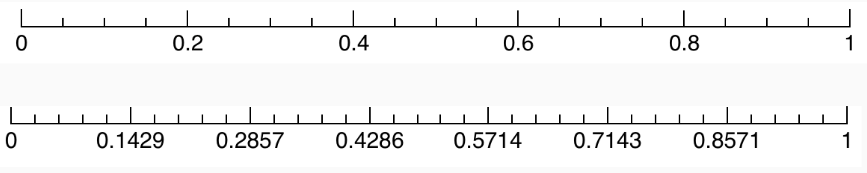

Nevertheless, in some cases, it is useful to have non optimized labelling.
#### Other kinds of axis
In addition to the normal linear numeric axis axis ROOT provides also:
* Alphanumeric labelled axis. They are produced when a histogram with alphanumeric labels is plotted.
* Logarithmic axis. Set with `ROOT.gPad.SetLogx()`.  **Try it** (`ROOT.gPad.SetLogy()` for the Y axis)
* Time axis.

In [28]:
# Let's set a logarithmic axis with ROOT.gPad.SetLogy()
ROOT.gPad.SetLogx()
ROOT.gPad.SetLogy()
c.Draw()


### Fine tuning of axis labels
When a specific fine tuning of an individual label is required, for instance changing its color, its font, its angle or even changing the label itself the method ChangeLabel can be used on any axis.

For instance, in our example, imagine we would like to highlight more the X label with the maximum deviation by putting it in red. It is enough to do:

In [ ]:
graph.GetXaxis().ChangeLabel(3,-1,-1,-1,ROOT.kRed) # canvia el color del tercer numero de l'eix
ROOT.gPad.SetLogx(0) # recuperam els eixos lineals
ROOT.gPad.SetLogy(0)
c.Draw()

### Legend
ROOT provides a powerful class to build a legend: TLegend. In our example the legend is build as follow:


In [ ]:
legend = ROOT.TLegend(.1,.7,.3,.9,"Lab. Lesson 1")
legend.AddEntry(graph,"Exp. Points","PE") # del gràfic, per això posa graph davant
legend.AddEntry(f,"Th. Law","L")          # de la funció, f
legend.Draw()
c.Draw()

* The `TLegend` constructor defines the legend **position and its title**. 
* Each legend item is added with method **`AddEntry`** which specify:
   * **an object to be part of the legend** (by name or by variable), 
   * the **text of the legend**
   * the **graphics attributes to be legended**: "L" for TAttLine, "P" for TAttMarker, "E" for error bars etc … 



`ROOT` also provides an automatic way to produce a legend from the graphics objects present in the pad. The method **TPad.BuildLegend()**
* In our example try `ROOT.gPad.BuildLegend()`
This is a quick way to proceed, but for a plot ready for publication it is recommended to use the method previously described. 

In [ ]:
legend = ROOT.gPad.BuildLegend() # llegenda automàtica
legend.Draw()
c.Draw()


### Annotations
Often the various parts of a plot we already saw are not enough to convey the complete message this plot should. Additional annotations elements are needed to complete and reinforce the message the plot should give.
`ROOT` provides a collection of basic graphics primitives allowing to draw such annotations. Here a non exhaustive list: 
* **`TText`** and **`TLatex`** to draw text.
* **`TArrow`** to draw all kinds of arrows
* **`TBox`**, `**TEllipse`** to draw boxes and ellipses.
* etc ...

In our example we added an annotation pointing the "maximum deviation". It consists of a simple arrow and a text:

In [33]:
# Draw an arrow on the canvas
arrow = ROOT.TArrow(8,8,6.2,23,0.02,"|>")
arrow.SetLineWidth(2)
arrow.Draw()

# Add some text to the plot
text = ROOT.TLatex(8.2,7.5,"#splitline{Maximum}{Deviation}")
text.Draw()

c.Draw()

* Notice changing the canvas size does not affect the pointed position.